In [ ]:
# Imports
import os

# Set the JAX_PLATFORMS environment variable to "cpu"
os.environ["JAX_PLATFORMS"] = "cpu"

import pathlib

current_dir = pathlib.Path().parent.resolve()
new_folder_path = current_dir / "plots"
new_folder_path.mkdir(parents=True, exist_ok=True)


import random

import numpy as np
import matplotlib.pyplot as plt
import jax
from jax.random import randint
from numpy import ones, zeros, sum, float32, int32, logical_or

from scipy.fft import fft, fftfreq

from kandel.utility.checkpoint_loader import load_environment, load_policy

import scienceplots  # noqa: F401

plt.style.use(["science", "grid"])

In [3]:
def evaluate_torque(
    random_key,
    # environment
    envs,
    # policy
    forward_fcn,
    update_fcn,
    policy_params,
    # timing params
    episode_steps: int,
    environment_interval: float,
    hebbian_update_interval: float,
    # life-time logging
    record_policy: bool = False,
    record_env_info: bool = False,
    record_stepwise_rewards: bool = False,
    # record_sensordata: bool = False,
    interrupt: float = None,
):
    num_envs = 1
    if hasattr(envs, "num_envs"):
        num_envs = envs.num_envs

    # episode statistics
    active_episode = ones((num_envs,), dtype=int32)
    cumulative_lengths = zeros((num_envs,), dtype=int32)
    cumulative_rewards = zeros((num_envs,), dtype=float32)

    # Update management
    # Network weights are update asynchronously to forward passes.
    # The network's dynamics can be independent of environment flow.
    assert environment_interval > 0.0, (
        "Environment interaction interval must be greater than 0."
    )
    assert hebbian_update_interval > 0.0, (
        "Hebbian update interval must be greater than 0."
    )

    # floating-point operations are not reliable for tracking the frequencies,
    # therefore we transform the intervals relative to `episode_steps` to integers.
    # Episode steps define the number of simulation steps and therefore the world
    # frequency.
    total_time = episode_steps * environment_interval
    total_steps = int(
        total_time / min(environment_interval, hebbian_update_interval)
    )

    total_environment_steps = int(total_time / environment_interval)
    total_update_steps = int(total_time / hebbian_update_interval)

    relative_environment_steps = int(total_steps / total_environment_steps)
    relative_update_steps = int(total_steps / total_update_steps)

    # start environment evaluation
    seeds = randint(random_key, (num_envs,), 0, 2e15).tolist()
    if num_envs == 1:
        seeds = seeds[0]

    observations, infos = envs.reset(seed=seeds)

    # log policy parameters
    if record_policy:
        policy_params_history = [policy_params]

    if record_stepwise_rewards:
        stepwise_rewards = []

    motor_history = []
    sensor_history = []

    interrupt_flag = False

    # environment loop
    for time_step in range(total_steps):
        # environment and forward step
        if time_step % relative_environment_steps == 0:
            # forward step
            policy_params, actions = forward_fcn(policy_params, observations)

            # Record torque
            motor_history.append(actions)
            sensor_history.append(observations)

            (
                observations,
                rewards,
                terminations,
                truncations,
                infos,
            ) = envs.step(actions)
            dones = logical_or(terminations, truncations)

            if record_stepwise_rewards:
                stepwise_rewards.append(rewards)

            # computing episode statistics
            # INFO: EpisodeStatistics wrapper, I have not found to be reliable
            # for evolutionary setting. Therefore a hacky solution for this.
            cumulative_lengths += active_episode
            cumulative_rewards += rewards * active_episode
            active_episode *= 1 - dones

        # update step
        if time_step % relative_update_steps == 0 and not interrupt_flag:
            policy_params = update_fcn(policy_params, rewards)

        # add policy parameters
        if record_policy:
            policy_params_history.append(policy_params)

        if isinstance(interrupt, float):
            if total_steps * interrupt < time_step:
                interrupt_flag = True

    # Generate function output
    out = (
        cumulative_rewards,
        cumulative_lengths,
        motor_history,
        sensor_history,
    )

    if record_policy:
        out += (policy_params_history,)

    if record_stepwise_rewards:
        out += (stepwise_rewards,)

    return out

In [4]:
def compute_euclidian_distance(weight_history):
    euclidian_history = []
    layers = weight_history[0]["kernel_params"].keys()

    for t in range(len(weight_history) - 1):
        mse = 0.0
        for layer in layers:
            params_t1 = weight_history[t]["kernel_params"][layer]["W"]
            params_t2 = weight_history[t + 1]["kernel_params"][layer]["W"]
            mse += np.linalg.norm(params_t2 - params_t1)
        euclidian_history.append(mse)
    euclidian_history = np.array(euclidian_history)
    return euclidian_history

In [5]:
def calculate_frequency(signal, sampling_rate=1.0):
    N = len(signal)
    yf = fft(signal)
    xf = fftfreq(N, sampling_rate)[: N // 2]
    spectrum = 2.0 / N * np.abs(yf[: N // 2])
    return xf, spectrum

In [ ]:
from gymnasium.wrappers import RecordVideo

selection_seed = 0
environment_seed = 4
num_neurons = 80
random.seed(a=selection_seed)

checkpoint = 999
policy_id = 0
environment_id = None
eval_fcn = evaluate_torque
episode_length = 1000
sampling_rate = 0.05

checkpoint_directory = "/home/alexanderdittrich/Downloads/ocarina/250418093513-halfcheetah-mlp-hebbian-adaptive-es-4/"

env, info = load_environment(
    checkpoint_directory=checkpoint_directory,
    checkpoint=checkpoint,
    environment_id=environment_id,
    render_mode="rgb_array",
)

policy, policy_params = load_policy(
    checkpoint_directory=checkpoint_directory,
    checkpoint=checkpoint,
    policy_id=policy_id,
)

forward_fcn = jax.jit(policy.forward)
update_fcn = jax.jit(policy.update)
reset_fcn = policy.reset

rng = jax.random.key(environment_seed)
rng_reset, rng_eval = jax.random.split(rng)

policy_params = reset_fcn(policy_params, rng_reset)

rewards, _, torque_history, sensor_history, network_history, step_rewards = (
    eval_fcn(
        random_key=rng_eval,
        envs=env,
        forward_fcn=forward_fcn,
        update_fcn=update_fcn,
        policy_params=policy_params,
        episode_steps=episode_length,
        environment_interval=info["step_interval"],
        hebbian_update_interval=info["update_interval"],
        record_policy=True,
        record_stepwise_rewards=True,
    )
)

print("Total reward: ", rewards)

layers = list(network_history[0]["kernel_params"].keys())

indices = []
for _ in range(num_neurons):
    selected_layer = random.choice(layers)
    array_shape = network_history[0]["kernel_params"][selected_layer][
        "W"
    ].shape

    # Random indices
    ind_1 = random.randint(0, array_shape[0] - 1)
    ind_2 = random.randint(0, array_shape[1] - 1)

    indices.append((selected_layer, ind_1, ind_2))

neuron_ts = []
for l in indices:
    neuron_signal = []
    for t in range(len(network_history)):
        neuron_signal.append(
            network_history[t]["kernel_params"][l[0]]["W"][l[1], l[2]]
        )

    neuron_ts.append(neuron_signal)

torque_history = np.array(torque_history)
neuron_ts = np.array(neuron_ts).T

In [7]:
env, info = load_environment(
    checkpoint_directory=checkpoint_directory,
    checkpoint=checkpoint,
    environment_id=environment_id,
    render_mode="rgb_array",
)

env = RecordVideo(
    env,
    video_folder="/home/alexanderdittrich/workspace/hebbian-attractors/notebooks/plots/",
    name_prefix="interrupt_lca",
    episode_trigger=lambda x: True,
)

rewards, _, _, _, network_history_interrupt, step_rewards_interrupt = eval_fcn(
    random_key=rng_eval,
    envs=env,
    forward_fcn=forward_fcn,
    update_fcn=update_fcn,
    policy_params=policy_params,
    episode_steps=episode_length,
    environment_interval=info["step_interval"],
    hebbian_update_interval=info["update_interval"],
    record_policy=True,
    record_stepwise_rewards=True,
    interrupt=0.5,
)

env.close()
print("Total reward: ", rewards)

/home/alexanderdittrich/miniconda3/envs/hebb/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /home/alexanderdittrich/workspace/hebbian-attractors/notebooks/plots folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
libdecor-gtk-WARNING: Failed to initialize GTK
Failed to load plugin 'libdecor-gtk.so': failed to init


Total reward:  [4013.949]


In [9]:
checkpoint_directory = "/home/alexanderdittrich/Downloads/ocarina/250420010524-halfcheetah-mlp-hebbian-adaptive-es-15"

env, info = load_environment(
    checkpoint_directory=checkpoint_directory,
    checkpoint=checkpoint,
    environment_id=environment_id,
    render_mode="rgb_array",
)

policy, policy_params = load_policy(
    checkpoint_directory=checkpoint_directory,
    checkpoint=checkpoint,
    policy_id=policy_id,
)

forward_fcn = jax.jit(policy.forward)
update_fcn = jax.jit(policy.update)
reset_fcn = policy.reset

rng = jax.random.key(2)
rng_reset, rng_eval = jax.random.split(rng)

policy_params = reset_fcn(policy_params, rng_reset)

rew_, _, _, _, network_history_as, step_rewards_as = eval_fcn(
    random_key=rng_eval,
    envs=env,
    forward_fcn=forward_fcn,
    update_fcn=update_fcn,
    policy_params=policy_params,
    episode_steps=episode_length,
    environment_interval=info["step_interval"],
    hebbian_update_interval=info["update_interval"],
    record_policy=True,
    record_stepwise_rewards=True,
    # interrupt=0.5,
)
print("Total reward: ", rew_)

env = RecordVideo(
    env,
    video_folder="/home/alexanderdittrich/workspace/hebbian-attractors/notebooks/plots/",
    name_prefix="interrupt_fpa",
    episode_trigger=lambda x: True,
)

rew, _, _, _, network_history_as_interrupt, step_rewards_as_interrupt = (
    eval_fcn(
        random_key=rng_eval,
        envs=env,
        forward_fcn=forward_fcn,
        update_fcn=update_fcn,
        policy_params=policy_params,
        episode_steps=episode_length,
        environment_interval=info["step_interval"],
        hebbian_update_interval=info["update_interval"],
        record_policy=True,
        record_stepwise_rewards=True,
        interrupt=0.5,
    )
)
print("Total reward: ", rew)
env.close()
euclidian_history_ws = compute_euclidian_distance(network_history_interrupt)
euclidian_history_as = compute_euclidian_distance(network_history_as_interrupt)

Total reward:  [7282.552]


/home/alexanderdittrich/miniconda3/envs/hebb/lib/python3.12/site-packages/gymnasium/wrappers/rendering.py:283: UserWarning: WARN: Overwriting existing videos at /home/alexanderdittrich/workspace/hebbian-attractors/notebooks/plots folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
libdecor-gtk-WARNING: Failed to initialize GTK
Failed to load plugin 'libdecor-gtk.so': failed to init


Total reward:  [7911.434]


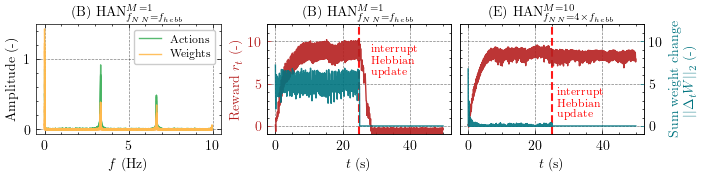

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(7, 1.75), constrained_layout=True)
ts = np.arange(0, len(torque_history) * sampling_rate, sampling_rate)
for ax in axs[1:]:
    ax.set_xlabel("$t$ (s)")
    ax.axvline(
        ts[int(0.5 * episode_length)],
        color="r",
        alpha=0.9,
        linewidth=1.5,
        linestyle="dashed",
    )

axs[1].annotate(
    "interrupt\n Hebbian\n update", (28.5, 6.0), fontsize=8, color="r"
)
axs[2].annotate(
    "interrupt\n Hebbian\n update", (26.5, 1.0), fontsize=8, color="r"
)

axs[1].plot(
    ts,
    step_rewards_interrupt,
    label="Hebbian NN with WS",
    color="#B51F1F",
    alpha=0.9,
)
axs0 = axs[1].twinx()
axs0.plot(
    ts,
    euclidian_history_ws,
    label="Hebbian NN with AS",
    color="#007480",
    alpha=0.9,
)

axs[2].plot(
    ts,
    step_rewards_as_interrupt,
    label="Hebbian NN with WS and AS",
    color="#B51F1F",
    alpha=0.9,
)
axs1 = axs[2].twinx()
axs1.plot(
    ts,
    euclidian_history_as,
    label="Hebbian NN with AS",
    color="#007480",
    alpha=0.9,
)


axs[1].set_ylabel("Reward $r_t$ (-)", color="#B51F1F")
axs1.set_ylabel(
    "Sum weight change\n" + "$||\\Delta_t W ||_2$ (-)", color="#007480"
)

# ax.legend(loc="lower center", ncol=1, bbox_to_anchor=(0.5, -0.7))

# axs[1].set_title("(B) Hebbian NN with MN\n($f_{env} = f_{hebb}$)", fontsize=10)
# axs[2].set_title(
#     "(E) Hebbian NN with MN\nand MA ($f_{env} > f_{hebb}$)", fontsize=10
# )

axs[1].set_title(r"(B) HAN$^{M=1}_{f_{NN}=f_{hebb}}$", fontsize=10)
axs[2].set_title(r"(E) HAN$^{M=10}_{f_{NN}=4 \times f_{hebb}}$", fontsize=10)

axs[1].set_ylim(-1, 12)
axs0.set_ylim(-1, 12)
axs1.set_ylim(-1, 12)

axs[2].set_ylim(-1, 12)
axs[1].set_ylim(-1, 12)

axs0.grid(False)
axs1.grid(False)


for k in range(torque_history.shape[1]):
    xf, spectrum = calculate_frequency(torque_history[:, k], sampling_rate)

    label = "Actions" if k == 0 else None
    axs[0].plot(
        xf,
        spectrum,
        alpha=0.9,
        color="#46b361",
        label=label,
    )


for idx in range(neuron_ts.shape[1]):
    xf, spectrum = calculate_frequency(neuron_ts[:, idx], sampling_rate)

    label = "Weights" if idx == 0 else None
    axs[0].plot(
        xf,
        spectrum,
        alpha=0.9,
        linestyle="solid",
        color="#ffba4d",
        label=label,
    )

# axs[0].set_title("(B) Hebbian NN with MN\n($f_{env} = f_{hebb}$)", fontsize=10)
axs[0].set_title(r"(B) HAN$^{M=1}_{f_{NN}=f_{hebb}}$", fontsize=10)

axs[0].grid(True)
axs[0].set_ylabel("Amplitude (-)")
axs[0].set_xlabel("$f$ (Hz)")
axs[0].legend(fontsize=8)

axs[1].tick_params(axis="y", colors="#B51F1F")
axs1.tick_params(axis="y", color="#007480")

axs0.tick_params(right=False, labelright=False)
axs[2].tick_params(left=False, labelleft=False)

# fig.tight_layout()
fig.savefig("plots/cheetah_weight_freeze.pdf", transparent=True)
fig.savefig("plots/cheetah_weight_freeze.svg", transparent=True)

plt.show()